# Example XX Using the `MIHMS.prep` PRMS parameters module

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.path import Path as mpPath
from matplotlib.collections import PathCollection

In [2]:
src_root = (Path('..') / 'src').resolve()
os.chdir(src_root)

from mihms.prep import prms as pprms

In [3]:
grid_pth = Path('D:/ArcGIS_Projects/Yellowstone/Upper Yellowstone/prms/UY_prms_grid.shp')
geom_grid = gpd.read_file(grid_pth)
wgs_grid = geom_grid.to_crs(4326)

## Creating a parameters object

## Populating the parameters object

## Cascades - a special type of parameters object

## Parameter utilities - select, remove, set, or change

In [4]:
out_pth = Path(os.getcwd()).parent / 'example/Yellowstone'

In [5]:
parm_nc = pprms.PRMSParameters.load_netcdf(out_pth / 'UY_params.nc')

In [6]:
parm_nc.parameters

<xarray.Dataset>
Dimensions:               (nlake_hrus: 221, nrain: 104, ndepl: 1, one: 1,
                           nhru: 45244, nsub: 19, nsegment: 1352,
                           ncascade: 88141, nlake: 1, nmonths: 12, ntemp: 104,
                           nssr: 45244, ngw: 45244, ndeplval: 11)
Coordinates:
  * nlake_hrus            (nlake_hrus) int64 343 344 345 ... 45073 45093 45094
  * nrain                 (nrain) int64 0 1 2 3 4 5 6 ... 98 99 100 101 102 103
  * ndepl                 (ndepl) int64 1
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nlake,
                                nmonths, ntemp, nssr, ngw, ndeplval
Data variables: (12/117)
    elev_units            (one) int64 1
    hru_type              (nhru) int64 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int64 19 19 19 19 19 19 19 ... 17 16 1 17 1 15
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 45.11 45.11 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.2 -110.8
    lake_hru_id           (nhru) int64 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    ...                    ...
    ppt_rad_adj           (nmonths, nhru) float64 0.02 0.02 0.02 ... 0.02 0.02
    radj_sppt             (nhru) float64 0.44 0.44 0.44 0.44 ... 0.44 0.44 0.44
    radj_wppt             (nhru) float64 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    radmax                (nmonths, nhru) float64 0.8 0.8 0.8 ... 0.8 0.8 0.8
    tmax_index            (nmonths, nhru) float64 50.0 50.0 50.0 ... 50.0 50.0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

In [15]:
ids = np.array([3, 6])

In [6]:
parm_nc.change_parameter_by_subbasin('carea_max', np.array([0.9, 0.88, 0.7, 0.86, 0.55]), np.array([1, 2, 3, 4, 5]))

In [8]:
parm_nc.select_parameters('carea_max')

<xarray.DataArray 'carea_max' (nhru: 45244)>
array([1.      , 1.      , 1.      , ..., 1.      , 1.      , 0.999999])
Dimensions without coordinates: nhru
Attributes:
    default:  0.6
    desc:     Maximum contributing area
    help:     Maximum possible area contributing to surface runoff expressed ...
    maximum:  1
    minimum:  0
    modules:  ['srunoff', 'srunoff_smidx', 'srunoff_carea']
    type:     F
    units:    decimal fraction
    dims:     nhru

In [21]:
sbsn = parm_nc.select_parameters('hru_subbasin').values

In [26]:
ids = np.argwhere(np.isin(sbsn, np.array([1, 19]))).ravel()

In [28]:
parm_nc.change_parameter('carea_max', values=0.8, dim='nhru', idx={'nhru': ids})

In [7]:
parm_nc.select_parameters(['hru_aspect', 'hru_elev'])

<xarray.Dataset>
Dimensions:     (nlake_hrus: 221, nrain: 104, ndepl: 1, nhru: 45244)
Coordinates:
  * nlake_hrus  (nlake_hrus) int64 343 344 345 346 ... 45067 45073 45093 45094
  * nrain       (nrain) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103
  * ndepl       (ndepl) int64 1
Dimensions without coordinates: nhru
Data variables:
    hru_aspect  (nhru) float64 302.0 262.5 315.4 249.8 ... 208.5 297.8 54.66
    hru_elev    (nhru) float64 1.794e+03 1.711e+03 ... 2.331e+03 2.319e+03

In [4]:
parm_prms = pprms.PRMSParameters.load_paramfile(out_pth / 'UY_calib_params.param')

------------------------------------
Reading parameter file : UY_calib_params.param
------------------------------------


In [11]:
parm_prms.parameters

<xarray.Dataset>
Dimensions:               (nlake: 1, nsegment: 1352, nmonths: 12, nhru: 45244,
                           one: 1, nssr: 45244, ngw: 45244)
Dimensions without coordinates: nlake, nsegment, nmonths, nhru, one, nssr, ngw
Data variables: (12/37)
    lake_coef             (nlake) float64 0.1
    K_coef                (nsegment) float64 24.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    x_coef                (nsegment) float64 0.01 0.01 0.01 ... 0.01 0.01 0.01
    adjmix_rain           (nmonths, nhru) float64 1.0 1.0 1.0 ... 1.0 1.0 1.0
    tmax_allsnow          (nmonths, nhru) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    tmax_allrain_offset   (nmonths, nhru) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...                    ...
    ppt_rad_adj           (nmonths, nhru) float64 0.02 0.02 0.02 ... 0.02 0.02
    radj_sppt             (nhru) float64 0.44 0.44 0.44 0.44 ... 0.44 0.44 0.44
    radj_wppt             (nhru) float64 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    radmax                (nmonths, nhru) float64 0.8 0.8 0.8 ... 0.8 0.8 0.8
    tmax_index            (nmonths, nhru) float64 50.0 50.0 50.0 ... 50.0 50.0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

original value = 0.014

In [5]:
parm_prms.select_parameters('jh_coef')

<xarray.DataArray 'jh_coef' (nmonths: 12, nhru: 45244)>
array([[0.014, 0.014, 0.014, ..., 0.014, 0.014, 0.014],
       [0.014, 0.014, 0.014, ..., 0.014, 0.014, 0.014],
       [0.014, 0.014, 0.014, ..., 0.014, 0.014, 0.014],
       ...,
       [0.014, 0.014, 0.014, ..., 0.014, 0.014, 0.014],
       [0.014, 0.014, 0.014, ..., 0.014, 0.014, 0.014],
       [0.014, 0.014, 0.014, ..., 0.014, 0.014, 0.014]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.014
    desc:       Monthly air temperature coefficient for each HRU - Jensen-Haise
    help:       Monthly (January to December) air temperature coefficient use...
    maximum:    1.5
    minimum:    -0.5
    modules:    ['potet_jh']
    type:       F
    units:      per degrees Fahrenheit
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

In [6]:
parm_prms.change_parameter(name='jh_coef', values=0.5)
parm_prms.select_parameters('jh_coef')

<xarray.DataArray 'jh_coef' (nmonths: 12, nhru: 45244)>
array([[0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       ...,
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.014
    desc:       Monthly air temperature coefficient for each HRU - Jensen-Haise
    help:       Monthly (January to December) air temperature coefficient use...
    maximum:    1.5
    minimum:    -0.5
    modules:    ['potet_jh']
    type:       F
    units:      per degrees Fahrenheit
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

In [15]:
parm_prms.change_parameter(name='jh_coef', values=np.random.rand(12), dim='nmonths', operation='replace')
parm_prms.select_parameters('jh_coef')

<xarray.DataArray 'jh_coef' (nmonths: 12, nhru: 45244)>
array([[0.28907812, 0.28907812, 0.28907812, ..., 0.28907812, 0.28907812,
        0.28907812],
       [0.76306656, 0.76306656, 0.76306656, ..., 0.76306656, 0.76306656,
        0.76306656],
       [0.20278686, 0.20278686, 0.20278686, ..., 0.20278686, 0.20278686,
        0.20278686],
       ...,
       [0.05017795, 0.05017795, 0.05017795, ..., 0.05017795, 0.05017795,
        0.05017795],
       [0.94486773, 0.94486773, 0.94486773, ..., 0.94486773, 0.94486773,
        0.94486773],
       [0.47199886, 0.47199886, 0.47199886, ..., 0.47199886, 0.47199886,
        0.47199886]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.014
    desc:       Monthly air temperature coefficient for each HRU - Jensen-Haise
    help:       Monthly (January to December) air temperature coefficient use...
    maximum:    1.5
    minimum:    -0.5
    modules:    ['potet_jh']
    type:       F
    units:      per degrees Fahrenheit
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

In [16]:
parm_prms.change_parameter(name='jh_coef', values=np.ones(12), dim='nmonths', operation='add')
parm_prms.select_parameters('jh_coef')

<xarray.DataArray 'jh_coef' (nmonths: 12, nhru: 45244)>
array([[1.28907812, 1.28907812, 1.28907812, ..., 1.28907812, 1.28907812,
        1.28907812],
       [1.76306656, 1.76306656, 1.76306656, ..., 1.76306656, 1.76306656,
        1.76306656],
       [1.20278686, 1.20278686, 1.20278686, ..., 1.20278686, 1.20278686,
        1.20278686],
       ...,
       [1.05017795, 1.05017795, 1.05017795, ..., 1.05017795, 1.05017795,
        1.05017795],
       [1.94486773, 1.94486773, 1.94486773, ..., 1.94486773, 1.94486773,
        1.94486773],
       [1.47199886, 1.47199886, 1.47199886, ..., 1.47199886, 1.47199886,
        1.47199886]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.014
    desc:       Monthly air temperature coefficient for each HRU - Jensen-Haise
    help:       Monthly (January to December) air temperature coefficient use...
    maximum:    1.5
    minimum:    -0.5
    modules:    ['potet_jh']
    type:       F
    units:      per degrees Fahrenheit
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

In [17]:
parm_prms.change_parameter(name='jh_coef', values=np.ones(12)*10, dim='nmonths', operation='multiply')
parm_prms.select_parameters('jh_coef')

<xarray.DataArray 'jh_coef' (nmonths: 12, nhru: 45244)>
array([[12.89078121, 12.89078121, 12.89078121, ..., 12.89078121,
        12.89078121, 12.89078121],
       [17.63066557, 17.63066557, 17.63066557, ..., 17.63066557,
        17.63066557, 17.63066557],
       [12.02786857, 12.02786857, 12.02786857, ..., 12.02786857,
        12.02786857, 12.02786857],
       ...,
       [10.50177953, 10.50177953, 10.50177953, ..., 10.50177953,
        10.50177953, 10.50177953],
       [19.44867727, 19.44867727, 19.44867727, ..., 19.44867727,
        19.44867727, 19.44867727],
       [14.71998862, 14.71998862, 14.71998862, ..., 14.71998862,
        14.71998862, 14.71998862]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.014
    desc:       Monthly air temperature coefficient for each HRU - Jensen-Haise
    help:       Monthly (January to December) air temperature coefficient use...
    maximum:    1.5
    minimum:    -0.5
    modules:    ['potet_jh']
    type:       F
    units:      per degrees Fahrenheit
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

In [18]:
parm_prms.change_parameter(name='jh_coef', values=np.random.rand(45244), dim='nhru', operation='replace')
parm_prms.select_parameters('jh_coef')

<xarray.DataArray 'jh_coef' (nmonths: 12, nhru: 45244)>
array([[0.82506002, 0.09597505, 0.28979766, ..., 0.24283891, 0.22726824,
        0.62791959],
       [0.82506002, 0.09597505, 0.28979766, ..., 0.24283891, 0.22726824,
        0.62791959],
       [0.82506002, 0.09597505, 0.28979766, ..., 0.24283891, 0.22726824,
        0.62791959],
       ...,
       [0.82506002, 0.09597505, 0.28979766, ..., 0.24283891, 0.22726824,
        0.62791959],
       [0.82506002, 0.09597505, 0.28979766, ..., 0.24283891, 0.22726824,
        0.62791959],
       [0.82506002, 0.09597505, 0.28979766, ..., 0.24283891, 0.22726824,
        0.62791959]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.014
    desc:       Monthly air temperature coefficient for each HRU - Jensen-Haise
    help:       Monthly (January to December) air temperature coefficient use...
    maximum:    1.5
    minimum:    -0.5
    modules:    ['potet_jh']
    type:       F
    units:      per degrees Fahrenheit
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

In [19]:
parm_prms.change_parameter(name='jh_coef', values=10.0, dim='nhru', operation='replace', idx={'nhru':0})
parm_prms.select_parameters('jh_coef')

<xarray.DataArray 'jh_coef' (nmonths: 12, nhru: 45244)>
array([[10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       ...,
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.014
    desc:       Monthly air temperature coefficient for each HRU - Jensen-Haise
    help:       Monthly (January to December) air temperature coefficient use...
    maximum:    1.5
    minimum:    -0.5
    modules:    ['potet_jh']
    type:       F
    units:      per degrees Fahrenheit
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

In [20]:
parm_prms.change_parameter(name='jh_coef', values=10.0, dim='nmonths', operation='replace', idx={'nmonths':0})
parm_prms.select_parameters('jh_coef')

<xarray.DataArray 'jh_coef' (nmonths: 12, nhru: 45244)>
array([[10.        , 10.        , 10.        , ..., 10.        ,
        10.        , 10.        ],
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       ...,
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959],
       [10.        ,  0.09597505,  0.28979766, ...,  0.24283891,
         0.22726824,  0.62791959]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.014
    desc:       Monthly air temperature coefficient for each HRU - Jensen-Haise
    help:       Monthly (January to December) air temperature coefficient use...
    maximum:    1.5
    minimum:    -0.5
    modules:    ['potet_jh']
    type:       F
    units:      per degrees Fahrenheit
    dims:       ('nmonth', 'nhru')
    file_name:  C:\Users\CNB968\OneDrive - MT\GitHub\MIHMS\example\Yellowston...

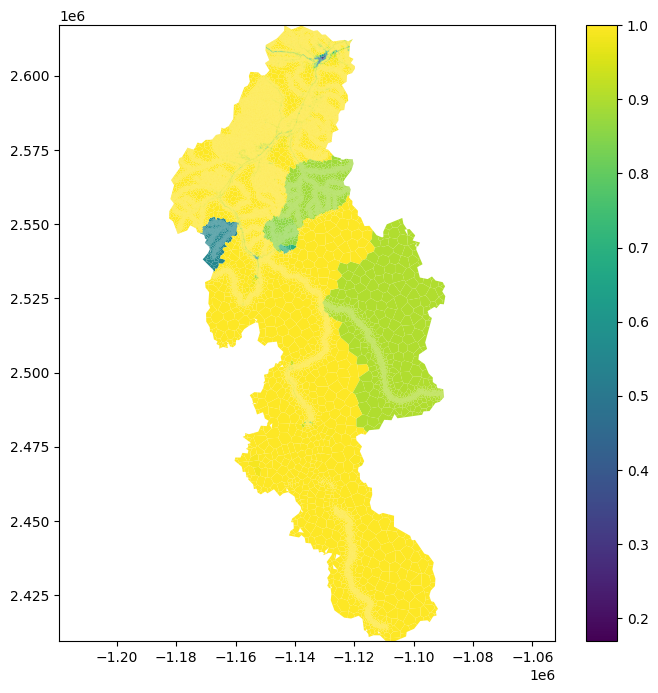

: 

In [ ]:
inarr = parm_nc.parameters['carea_max'].values

grd_vertices = geom_grid.geometry.get_coordinates()
gbnds = geom_grid.total_bounds
mp_pths = []
for i in geom_grid.index:
    np = mpPath(grd_vertices.loc[i,:].values)
    mp_pths.append(np)

kwargs = {}
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
collection = PathCollection(mp_pths)
collection.set_array(inarr)
vmin = kwargs.pop("vmin", None)
vmax = kwargs.pop("vmax", None)
kwargs["cmap"] = "viridis"
collection.set_clim(vmin=vmin, vmax=vmax)
collection.set(**kwargs)
ax.add_collection(collection)
ax.set_xlim(gbnds[0], gbnds[2])
ax.set_ylim(gbnds[1], gbnds[3])
fig.colorbar(collection, ax=ax)